#Installation & Setup

In [1]:
pip install librosa soundfile matplotlib torch torchvision

#Download Dataset

In [2]:
!kaggle datasets download -d mohammedabdeldayem/the-fake-or-real-dataset

Dataset URL: https://www.kaggle.com/datasets/mohammedabdeldayem/the-fake-or-real-dataset
License(s): GNU Lesser General Public License 3.0
100% 16.0G/16.0G [03:33<00:00, 80.6MB/s]



#Extract Dataset

In [3]:
import zipfile

zip_path = "/content/the-fake-or-real-dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/audio_dataset")

print("Dataset extracted successfully")

Dataset extracted successfully


#Explore Dataset Structure

In [4]:
import os

base_path = "/content/audio_dataset"

print(os.listdir(base_path))

['for-rerec', 'for-2sec', 'for-original', 'for-norm']


In [5]:
for root, dirs, files in os.walk("/content/audio_dataset"):
    print(root)

/content/audio_dataset
/content/audio_dataset/for-rerec
/content/audio_dataset/for-rerec/for-rerecorded
/content/audio_dataset/for-rerec/for-rerecorded/validation
/content/audio_dataset/for-rerec/for-rerecorded/validation/real
/content/audio_dataset/for-rerec/for-rerecorded/validation/fake
/content/audio_dataset/for-rerec/for-rerecorded/training
/content/audio_dataset/for-rerec/for-rerecorded/training/real
/content/audio_dataset/for-rerec/for-rerecorded/training/fake
/content/audio_dataset/for-rerec/for-rerecorded/testing
/content/audio_dataset/for-rerec/for-rerecorded/testing/real
/content/audio_dataset/for-rerec/for-rerecorded/testing/fake
/content/audio_dataset/for-2sec
/content/audio_dataset/for-2sec/for-2seconds
/content/audio_dataset/for-2sec/for-2seconds/validation
/content/audio_dataset/for-2sec/for-2seconds/validation/real
/content/audio_dataset/for-2sec/for-2seconds/validation/fake
/content/audio_dataset/for-2sec/for-2seconds/training
/content/audio_dataset/for-2sec/for-2seco

In [6]:
base_path = "/content/audio_dataset/for-norm/for-norm"

In [7]:
import os

train_real = os.path.join(base_path, "training", "real")
train_fake = os.path.join(base_path, "training", "fake")

print("Train Real:", len(os.listdir(train_real)))
print("Train Fake:", len(os.listdir(train_fake)))

Train Real: 26941
Train Fake: 26927


#Visualize Audio Spectrogram

In [8]:
import librosa

sample = os.path.join(train_real, os.listdir(train_real)[0])

audio, sr = librosa.load(sample, sr=16000)

print("Audio shape:", audio.shape)
print("Sample rate:", sr)

Audio shape: (46625,)
Sample rate: 16000


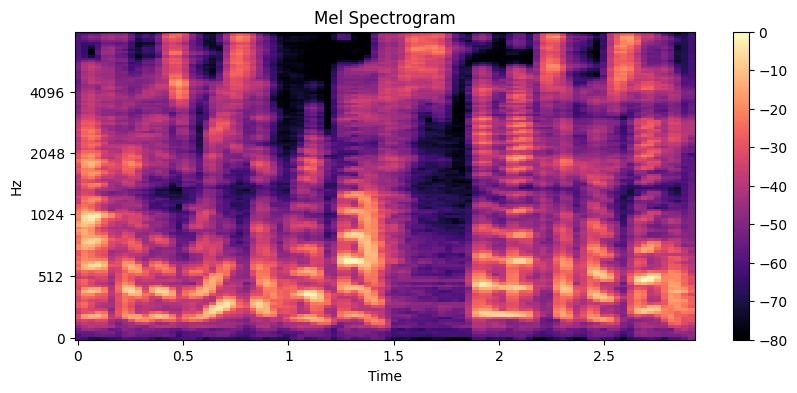

In [ ]:
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
mel_db = librosa.power_to_db(mel, ref=np.max)

plt.figure(figsize=(10,4))
librosa.display.specshow(mel_db, sr=sr, x_axis="time", y_axis="mel")
plt.colorbar()
plt.title("Mel Spectrogram")
plt.show()

#Set Test Paths

In [ ]:
base_path = "/content/audio_dataset/for-norm/for-norm"

test_real = base_path + "/testing/real"
test_fake = base_path + "/testing/fake"

In [ ]:
import os

print("Real test samples:", len(os.listdir(test_real)))
print("Fake test samples:", len(os.listdir(test_fake)))

Real test samples: 2264
Fake test samples: 2370


In [ ]:
real_file = os.path.join(test_real, os.listdir(test_real)[0])
fake_file = os.path.join(test_fake, os.listdir(test_fake)[0])

print("Real file:", real_file)
print("Fake file:", fake_file)

Real file: /content/audio_dataset/for-norm/for-norm/testing/real/file1832.wav_16k.wav_norm.wav_mono.wav_silence.wav
Fake file: /content/audio_dataset/for-norm/for-norm/testing/fake/file2312.wav_16k.wav_norm.wav_mono.wav_silence.wav


#Import Libraries

In [84]:
import os
import numpy as np
import librosa
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

#Feature Extraction Function

In [85]:
def audio_to_mel(file_path, sr=16000):
    audio, sr = librosa.load(file_path, sr=sr)

    # fix length (VERY IMPORTANT)
    audio = librosa.util.fix_length(audio, size=32000)

    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel)

    # normalize
    mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-6)

    # reshape → (128,128,1)
    mel_db = tf.image.resize(mel_db[..., np.newaxis], (128, 128))

    return mel_db.numpy()

# Data Augmentation - Audio Transformations

In [86]:
def augment_audio(audio, sr):

    noise = audio + 0.01 * np.random.randn(len(audio))
    shift = np.roll(audio, int(0.2 * sr))

    pitch = librosa.effects.pitch_shift(audio, sr=sr, n_steps=2)

    return [audio, noise, shift, pitch]

#Load Data Function

In [87]:
def load_data(real_path, fake_path, limit=100):

    X, y = [], []

    # REAL
    for f in os.listdir(real_path)[:limit]:
        try:
            path = os.path.join(real_path, f)
            audio, sr = librosa.load(path, sr=16000)

            for aug in augment_audio(audio, sr):
                aug = librosa.util.fix_length(aug, size=32000)

                mel = librosa.feature.melspectrogram(y=aug, sr=sr, n_mels=128)
                mel = librosa.power_to_db(mel)

                mel = (mel - mel.min()) / (mel.max() - mel.min() + 1e-6)
                mel = tf.image.resize(mel[..., np.newaxis], (128, 128))

                X.append(mel.numpy())
                y.append(0)
        except:
            pass

    # FAKE
    for f in os.listdir(fake_path)[:limit]:
        try:
            path = os.path.join(fake_path, f)
            audio, sr = librosa.load(path, sr=16000)

            for aug in augment_audio(audio, sr):
                aug = librosa.util.fix_length(aug, size=32000)

                mel = librosa.feature.melspectrogram(y=aug, sr=sr, n_mels=128)
                mel = librosa.power_to_db(mel)

                mel = (mel - mel.min()) / (mel.max() - mel.min() + 1e-6)
                mel = tf.image.resize(mel[..., np.newaxis], (128, 128))

                X.append(mel.numpy())
                y.append(1)
        except:
            pass

    return np.array(X), np.array(y)

#Load Training Data

In [88]:
X, y = load_data(train_real, train_fake, limit=100)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, y_train.shape)

(640, 128, 128, 1) (640,)


#Build CNN Model

In [89]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128,128,1)),

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#Train the Model

In [90]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=16,
    shuffle=True
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 37s 789ms/step - accuracy: 0.5844 - loss: 0.6845 - val_accuracy: 0.5000 - val_loss: 0.6941
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 27s 669ms/step - accuracy: 0.6281 - loss: 0.6389 - val_accuracy: 0.5000 - val_loss: 0.7045
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 27s 670ms/step - accuracy: 0.6750 - loss: 0.5895 - val_accuracy: 0.5000 - val_loss: 0.7213
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 27s 682ms/step - accuracy: 0.7406 - loss: 0.5307 - val_accuracy: 0.5000 - val_loss: 0.7396
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 42s 720ms/step - accuracy: 0.7328 - loss: 0.5309 - val_accuracy: 0.5000 - val_loss: 0.7340
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 38s 628ms/step - accuracy: 0.7547 - loss: 0.5057 - val_accuracy: 0.5000 - val_loss: 0.7838
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 41s 622ms/step - accuracy: 0.7734 - loss: 0.4998 - val_accuracy: 0.5000 - val_loss: 0.8455
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 42s 640ms/step - accuracy: 0.7703 - loss: 0.4774 - val_accu

In [91]:
import numpy as np

print("Train labels:", np.bincount(y_train))
print("Val labels:", np.bincount(y_val))

Train labels: [320 320]
Val labels: [80 80]


In [92]:
print(X_train.shape)
print(X_val.shape)

(640, 128, 128, 1)
(160, 128, 128, 1)


# Audio Preprocessing Function

In [93]:
# MUST be identical for train + val
def preprocess(audio):
    mel = librosa.feature.melspectrogram(y=audio, sr=16000, n_mels=128)
    mel = librosa.power_to_db(mel)

    mel = (mel - mel.min()) / (mel.max() - mel.min() + 1e-6)

    mel = tf.image.resize(mel[..., np.newaxis], (128,128))
    return mel.numpy()

#Train-Validation Split (80-20 with Stratified Sampling)

In [94]:
X, y = load_data(train_real, train_fake, limit=150)

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # VERY IMPORTANT
)

In [95]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", np.bincount(y_train))
print("y_val:", np.bincount(y_val))

X_train: (960, 128, 128, 1)
X_val: (240, 128, 128, 1)
y_train: [480 480]
y_val: [120 120]


# 3-Layer CNN Model with Batch Normalization

In [96]:
import tensorflow as tf
from tensorflow.keras import layers

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 1)),

    layers.Conv2D(32, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(1, activation='sigmoid')
])

## Model Compilation with Adam Optimizer and Binary Crossentropy

In [97]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## Model Training with Validation Split

In [98]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=16,
    shuffle=True
)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 60s 912ms/step - accuracy: 0.5885 - loss: 0.6925 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 40s 676ms/step - accuracy: 0.6448 - loss: 0.6108 - val_accuracy: 0.5000 - val_loss: 0.7031
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 40s 650ms/step - accuracy: 0.7010 - loss: 0.5481 - val_accuracy: 0.5000 - val_loss: 0.7287
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 41s 689ms/step - accuracy: 0.7396 - loss: 0.5124 - val_accuracy: 0.5000 - val_loss: 0.7932
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 41s 686ms/step - accuracy: 0.7844 - loss: 0.4581 - val_accuracy: 0.5000 - val_loss: 0.9462
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 38s 637ms/step - accuracy: 0.8115 - loss: 0.4255 - val_accuracy: 0.5000 - val_loss: 1.0286
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 57s 904ms/step - accuracy: 0.8427 - loss: 0.3844 - val_accuracy: 0.5000 - val_loss: 0.9934
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 40s 667ms/step - accuracy: 0.8156 - loss: 0.3979 - val_accu

## Model Evaluation

In [99]:
from sklearn.metrics import confusion_matrix, classification_report

pred = model.predict(X_val)

y_pred = (pred > 0.55).astype(int).flatten()

print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))

print("\nClassification Report:\n", classification_report(y_val, y_pred))

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 228ms/step
Confusion Matrix:
 [[117   3]
 [ 39  81]]

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.97      0.85       120
           1       0.96      0.68      0.79       120

    accuracy                           0.82       240
   macro avg       0.86      0.82      0.82       240
weighted avg       0.86      0.82      0.82       240



## Evaluating Model with 0.50 Classification Threshold

In [100]:
from sklearn.metrics import confusion_matrix, classification_report

pred = model.predict(X_val)

y_pred = (pred > 0.50).astype(int).flatten()

print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))

print("\nClassification Report:\n", classification_report(y_val, y_pred))

8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 574ms/step
Confusion Matrix:
 [[113   7]
 [ 24  96]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.94      0.88       120
           1       0.93      0.80      0.86       120

    accuracy                           0.87       240
   macro avg       0.88      0.87      0.87       240
weighted avg       0.88      0.87      0.87       240



#Saving the models

In [101]:
model.save("audio_deepfake_cnn_final.keras")

In [102]:
model.save("audio_deepfake_cnn_final.h5")

In [103]:
from google.colab import files

files.download("audio_deepfake_cnn_final.keras")
files.download("audio_deepfake_cnn_final.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Export Training History (Loss & Accuracy per Epoch)

In [104]:
import json

history_dict = history.history

with open("training_history.json", "w") as f:
    json.dump(history_dict, f)

In [105]:
from google.colab import files

files.download("training_history.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Finding Optimal Classification Threshold

In [115]:
import numpy as np
from sklearn.metrics import accuracy_score

pred_probs = model.predict(X_val).flatten()

best_t = 0
best_acc = 0

for t in np.arange(0.3, 0.8, 0.01):
    preds = (pred_probs > t).astype(int)
    acc = accuracy_score(y_val, preds)

    if acc > best_acc:
        best_acc = acc
        best_t = t

print("Best Threshold:", best_t)
print("Best Accuracy:", best_acc)

8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 533ms/step
Best Threshold: 0.47000000000000014
Best Accuracy: 0.8833333333333333


## Probability Calibration using Isotonic Regression

In [116]:
from sklearn.isotonic import IsotonicRegression

pred_probs = model.predict(X_val).flatten()

iso_reg = IsotonicRegression(out_of_bounds='clip')
iso_reg.fit(pred_probs, y_val)

calibrated_probs = iso_reg.transform(pred_probs)

8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step


## Final Evaluation with Optimal Threshold

In [117]:
from sklearn.metrics import confusion_matrix, classification_report

threshold = best_t  # use tuned threshold

y_pred = (pred_probs > threshold).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))

print("\nReport:")
print(classification_report(y_val, y_pred))

Confusion Matrix:
[[110  10]
 [ 18 102]]

Report:
              precision    recall  f1-score   support

           0       0.86      0.92      0.89       120
           1       0.91      0.85      0.88       120

    accuracy                           0.88       240
   macro avg       0.89      0.88      0.88       240
weighted avg       0.89      0.88      0.88       240



#Save the model

In [119]:
model.save("audio_deepfake_final_88.keras")

In [122]:
from google.colab import files

files.download("audio_deepfake_final_88.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>